#### J-function Development

In [17]:
%load_ext autoreload
%autoreload 2
import numpy as np
from scipy.spatial import KDTree
import pandas as pd
import matplotlib.pyplot as plt
from ecd_helperFunctions import *
from scipy.integrate import simpson
import seaborn as sns
from ecd_j_function import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
# Load in CSV as dataframe
sample_df = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/data/P2_BTC/S5_L1.csv')

j_functions, j_function_dict, summary_dict = calculate_j_function(df=sample_df,
                 distance_cols=['x_centroid', 'y_centroid'],
                 cell_a_label=0,
                 cell_b_label=1,
                 perturb_matrix=True,
                 roi_tile_size=300,
                 cell_label_col='tumor_immune',
                 r_max=300,
                 dr=5,
                 return_bboxes=True,
                 plot_j_function=False,
                 return_summary=True)


### Plotting the J-function and Cell Ratio with Linear Regression

In [46]:
# Convert summary_dict to a dataframe
summary_df = pd.DataFrame(summary_dict)

# Rename columns
summary_df = summary_df.rename(columns={
    'num_cell_a_points': 'immune',
    'num_cell_b_points': 'tumor'
})

# Calculate immune/tumor ratio
summary_df['ratio'] = summary_df['immune'] / summary_df['tumor']

# Calculate quartile labels based on ratio values
summary_df['ratio_quartile'] = pd.qcut(summary_df['ratio'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])


# Display first few rows
summary_df.head()


,roi_coordinates,bbox,r,J_r,AUC,mean_deviation,max_deviation,immune,tumor,ratio,ratio_quartile
0,"(42, 9)","[12877, 12898, 2915, 2999]","[2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5,...","[1.2195397272853539, 1.6999935491490263, 2.179...",41667.366939,105.058063,6144.397907,2,2,1.000000,Q4
1,"(42, 10)","[12806, 12899, 3000, 3299]","[2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5,...","[1.0661184134652084, 1.342367975115142, 1.2363...",-9.897090,-0.039015,1.000000,19,35,0.542857,Q3
2,"(42, 11)","[12712, 12898, 3304, 3599]","[2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5,...","[1.0785931169497271, 1.304840515205169, 1.1293...",-36.534054,-0.121072,1.000000,43,48,0.895833,Q3
3,"(42, 12)","[12747, 12893, 3600, 3893]","[2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5,...","[1.0926178198810188, 1.5321383166285778, 1.430...",-28.818557,-0.099784,1.000000,52,47,1.106383,Q4
4,"(42, 13)","[12814, 12899, 3904, 4180]","[2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5,...","[1.1171459893953055, 1.1319008770105146, 0.725...",-54.807511,-0.179508,1.000000,29,19,1.526316,Q4


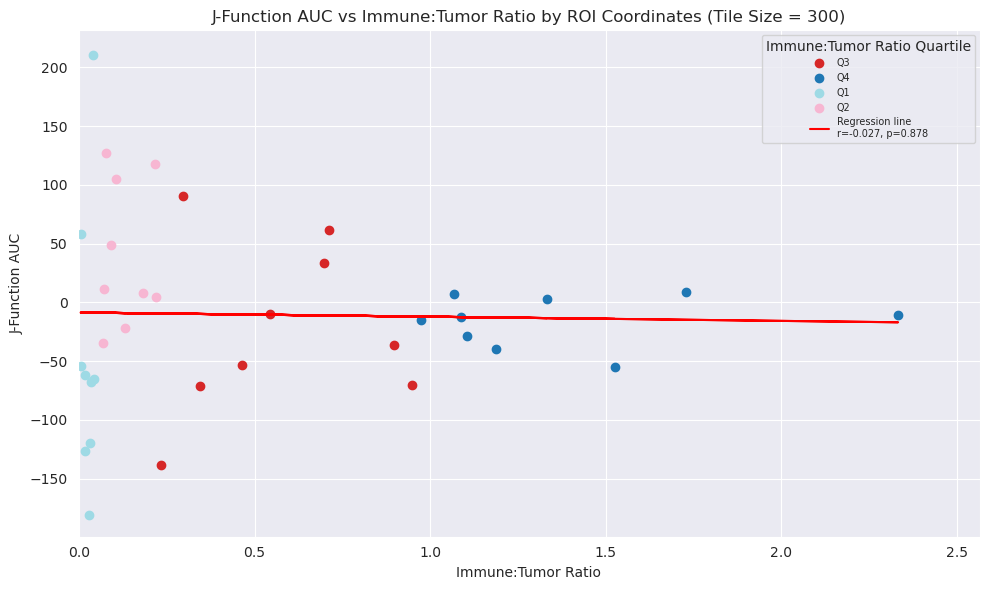

In [47]:
# Plot J-Function Max Sensitivity vs Immune:Tumor Ratio
plot_correlation(
    data=summary_df,
    data_col_name='AUC',
    sample_col_name='ratio_quartile',
    x_label='Immune:Tumor Ratio',
    y_label='J-Function AUC',
    title='J-Function AUC vs Immune:Tumor Ratio by ROI Coordinates (Tile Size = 300)',
    standard_axis_limits=False,
    show_plot=True,
    legend_size=7,
    legend_loc='upper right',
    legend_title='Immune:Tumor Ratio Quartile',
    output_path='/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/figures/regression_plots/tile_300j_function_auc_vs_ratio.png'
)

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import SymLogNorm

def plot_jfunc_auc_roi_explanations(data_dict, sample_df, bboxes,
                          x_col='x_centroid', y_col='y_centroid',
                          class_col='tumor_immune',
                          class_values=[0, 1], class_names=['Tumor', 'Immune'],
                          seaborn_style='darkgrid',
                          figure_size=(10, 8),
                          cmap=cm.RdBu_r,  # Reversed RdBu colormap
                          alpha=0.5, edgecolor='none', zorder_rect=2,
                          text_color='black', text_ha='center', text_va='center',
                          text_fontsize=8, text_zorder=3,
                          xlabel='X Position', ylabel='Y Position', title='GBM Sample S1 - ROI AUC Values',
                          colorbar_label='AUC Value',
                          save_path=None, dpi=300, bbox_inches='tight',
                          legend_kwargs=None, scatter_kwargs=None,
                          show_labels=True):
    # Set seaborn style
    sns.set_style(seaborn_style)
    
    # Extract AUC values from data_dict, excluding NaNs
    explainer_values = [value for value in data_dict.values() if not np.isnan(value)]
    
    # Handle edge cases with all NaNs or empty list
    if explainer_values:
        # Manually set vmin and vmax to cap extreme values
        vmin = -250  # Adjust as needed
        vmax = 1000  # Adjust as needed
        
        # Use SymLogNorm to handle both negative and positive values with extreme ranges
        linthresh = 50  # Linear range within +/- linthresh
        linscale = 1  # This affects the slope within the linear region
        
        norm = SymLogNorm(linthresh=linthresh, linscale=linscale, vmin=vmin, vmax=vmax)
    else:
        vmin, vmax = -1, 1
        linthresh = 0.1
        norm = SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax)
    
    print(f"Adjusted AUC value range: {vmin} to {vmax}")
    
    # Create figure with seaborn style
    plt.figure(figsize=figure_size)
    
    # Initialize default scatterplot options if not provided
    if scatter_kwargs is None:
        scatter_kwargs = {'s': 3, 'zorder': 1}
    else:
        # Ensure 's' and 'zorder' have default values if not provided
        scatter_kwargs.setdefault('s', 3)
        scatter_kwargs.setdefault('zorder', 1)
    
    # Scatter plot with separate classes for the legend
    for class_value, class_name in zip(class_values, class_names):
        subset = sample_df[sample_df[class_col] == class_value]
        sns.scatterplot(
            data=subset,
            x=x_col, y=y_col,
            label=class_name,
            **scatter_kwargs)
    
    # Initialize default legend options if not provided
    if legend_kwargs is None:
        legend_kwargs = {'title': 'Tumor/Immune', 'markerscale': 5, 'loc': 'upper right', 'fontsize': 8}
    else:
        # Ensure default values if not provided
        legend_kwargs.setdefault('title', 'Tumor/Immune')
        legend_kwargs.setdefault('markerscale', 5)
        legend_kwargs.setdefault('loc', 'upper right')
        legend_kwargs.setdefault('fontsize', 8)
    
    # Add legend for classes
    plt.legend(**legend_kwargs)
    
    # Draw heatmap rectangles
    for key in bboxes:
        min_x, max_x, min_y, max_y = bboxes[key]
        width = max_x - min_x
        height = max_y - min_y
    
        # Get AUC value, replacing NaN with zero
        explainer_value = data_dict.get(key, 0)
        explainer_value = explainer_value if not np.isnan(explainer_value) else 0
    
        # Clip the AUC value to vmin and vmax
        explainer_value = np.clip(explainer_value, vmin, vmax)
    
        # Determine color
        color = cmap(norm(explainer_value))
    
        # Draw rectangle
        rect = plt.Rectangle((min_x, min_y), width, height, facecolor=color,
                             alpha=alpha, edgecolor=edgecolor, zorder=zorder_rect)
        plt.gca().add_patch(rect)
    
        if show_labels:
            # Calculate the center of the rectangle
            center_x = min_x + width / 2
            center_y = min_y + height / 2
    
            # Add label at the center
            plt.text(center_x, center_y, f'{key}', color=text_color,
                     ha=text_ha, va=text_va, fontsize=text_fontsize, zorder=text_zorder)
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=plt.gca(), label=colorbar_label)
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches=bbox_inches)
    
    plt.show()

In [ ]:
j_function_auc = summary_dict['AUC']
bboxes = summary_dict['bbox']

# Create dictionary mapping coordinates to bounding boxes
bbox_dict = {}
for i in range(len(summary_dict['roi_coordinates'])):
    bbox_dict[summary_dict['roi_coordinates'][i]] = summary_dict['bbox'][i]

# Create dictionary mapping coordinates to auc
auc_dict = {}
for i in range(len(summary_dict['roi_coordinates'])):
    auc_dict[summary_dict['roi_coordinates'][i]] = summary_dict['AUC'][i]

print(auc_dict)

# Plot Heatmap with Explainer Values

# Define custom legend and scatter plot options
legend_options = {
    'title': 'Cell Type',
    'markerscale': 6,
    'loc': 'lower left',
    'fontsize': 10
}

scatter_options = {
    's': 5,
    'zorder': 2,
    'alpha': 0.7  # Additional scatter plot options
}

# Call the function with custom options
plot_jfunc_auc_roi_explanations(
    data_dict=auc_dict,
    sample_df=sample_df,
    bboxes=bbox_dict,
    legend_kwargs=legend_options,
    scatter_kwargs=scatter_options,
    title='GBM Sample S5_L1 (Tile Size = 500) - ROI J-function AUC Values',
    save_path='/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/figures/heatmaps/s5_l1_large_roi_cell_positions_with_j_function_auc_values.png',
    dpi=300,
    bbox_inches='tight',
    cmap=cm.RdBu,
    show_labels=False)


### Plot Max Sensitivity and Infidelity

In [4]:
results = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/j_function_results/infidelity_results.csv', index_col=0)
# Drop odd rows (indices 1,3,5,etc) while keeping header and even rows
#results = results.iloc[1::2].reset_index(drop=True)
#results.to_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/j_function_results/infidelity_results_cleaned.csv', index=False)

# Drop even rows (indices 0,2,4,etc) while keeping header and odd rows
results = results.iloc[::2].reset_index(drop=True)
results.to_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/j_function_results/max_sens_results_cleaned.csv', index=False)

In [51]:
save_dir = '/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/j_function_results/heatmaps'
#Create heatmap of results
plt.figure(figsize=(10,8))
results_df = pd.DataFrame(results).set_index('sample_name')
# Drop the unnamed index column
results_df = results_df.drop('Unnamed: 0', axis=1)

# Log transform the data
results_df = np.log10(results_df)

# Get actual min/max values from data for better color scaling
vmin = results_df.min().min()  # Get minimum value across all data
vmax = results_df.max().max()  # Get maximum value across all data

# Create heatmap with dynamic scale based on data range
sns.heatmap(results_df, cmap='Purples', annot=True, fmt='.2f',
            vmin=vmin, vmax=vmax,  # Use data-driven min/max values
            center=(vmax+vmin)/2)  # Center the colormap on the data

plt.xlabel('Simulation Type')
plt.ylabel('Sample')
plt.title('J-Function Infidelity Heatmap (Log Scale)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'infidelity_heatmap.png'))
plt.close()
